# Laboratorium 12 - Transformata Fouriera i szybka transformata Fouriera

# Import bibliotek i definicja funkcji transformaty Fouriera

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.io import wavfile
from mpl_toolkits.mplot3d import Axes3D


def dft(x):
    x = np.asarray(x, dtype=float)
    N = len(x)
    n = np.arange(N)
    k = n.reshape(-1, 1)
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x


def signal_x(n):
    return np.cos(0.314 * n) + 2 * np.cos(1.57 * n + 0.18)


def plot_amplitude_spectrum(X, title, use_shift=False):
    spectrum = np.fft.fftshift(X) if use_shift else X
    plt.figure(figsize=(8, 4))
    plt.stem(np.arange(len(spectrum)), np.abs(spectrum), basefmt=" ")
    plt.title(title)
    plt.xlabel("Indeks częstotliwości")
    plt.ylabel("Amplituda")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_audio_spectrum(X, fs, title, use_shift=True):
    spectrum = np.fft.fftshift(X) if use_shift else X
    freqs = np.fft.fftshift(np.fft.fftfreq(len(X), d=1 / fs))
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, np.abs(spectrum))
    plt.title(title)
    plt.xlabel("Częstotliwość [Hz]")
    plt.ylabel("Amplituda")
    plt.xlim(0, fs / 2)
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_fft2_mesh(F, title, use_shift=True, log_scale=True):
    spectrum = np.fft.fftshift(F) if use_shift else F
    amplitude = np.log1p(np.abs(spectrum)) if log_scale else np.abs(spectrum)

    rows, cols = amplitude.shape
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, amplitude, cmap="viridis", linewidth=0, antialiased=True)
    ax.set_title(title)
    ax.set_xlabel("Częstotliwość X")
    ax.set_ylabel("Częstotliwość Y")
    ax.set_zlabel("log(1 + amplituda)" if log_scale else "Amplituda")
    plt.show()


def freq_grid_2d(shape):
    rows, cols = shape
    wx = 2 * np.pi * np.fft.fftfreq(cols)
    wy = 2 * np.pi * np.fft.fftfreq(rows)
    return np.meshgrid(wx, wy)

# Zadanie 1

## Zadanie 1a

Sekwencja 32 próbek. Porównanie FFT z DFT

Maksymalna różnica DFT vs FFT: 1.28e-13


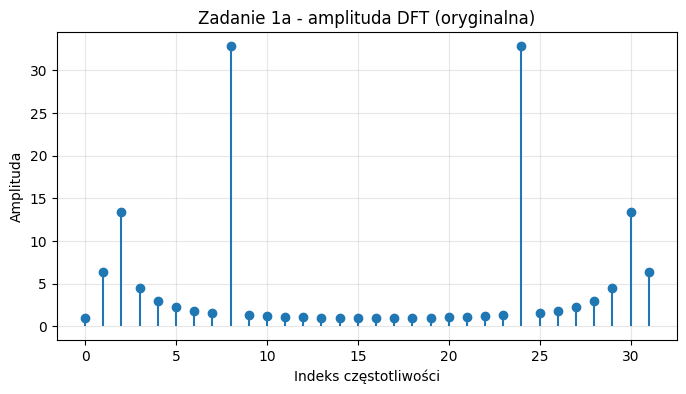

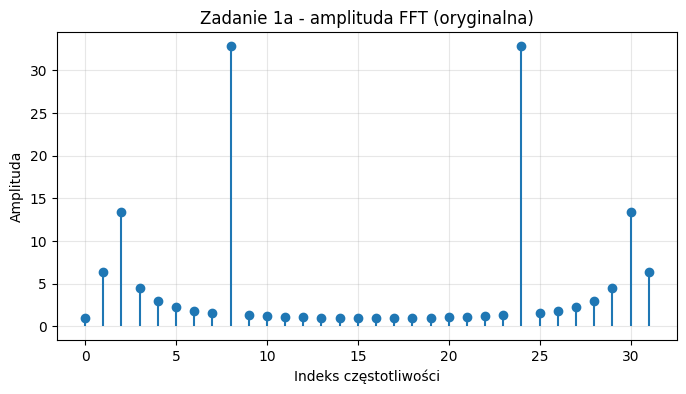

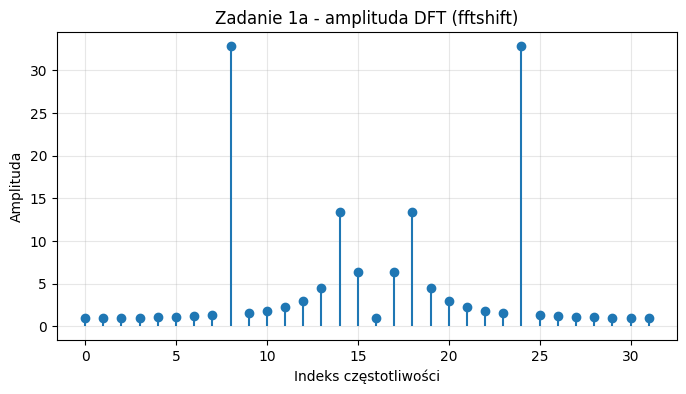

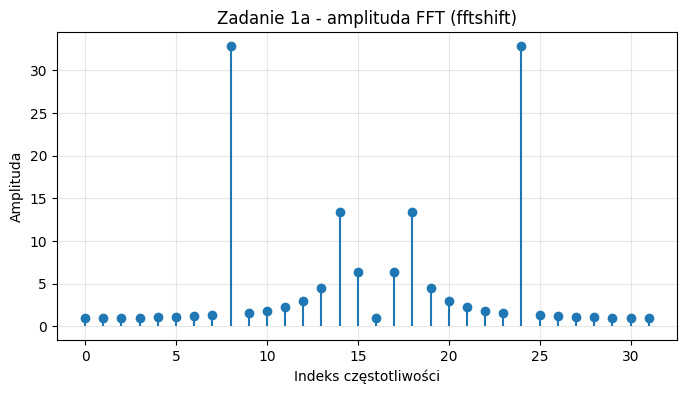

In [14]:
N = 32
n = np.arange(N)
x = signal_x(n)

X_dft = dft(x)
X_fft = np.fft.fft(x)

print(f"Maksymalna różnica DFT vs FFT: {np.max(np.abs(X_dft - X_fft)):.2e}")

plot_amplitude_spectrum(X_dft, "Zadanie 1a - amplituda DFT (oryginalna)")
plot_amplitude_spectrum(X_fft, "Zadanie 1a - amplituda FFT (oryginalna)")
plot_amplitude_spectrum(X_dft, "Zadanie 1a - amplituda DFT (fftshift)", use_shift=True)
plot_amplitude_spectrum(X_fft, "Zadanie 1a - amplituda FFT (fftshift)", use_shift=True)

## Zadanie 1b

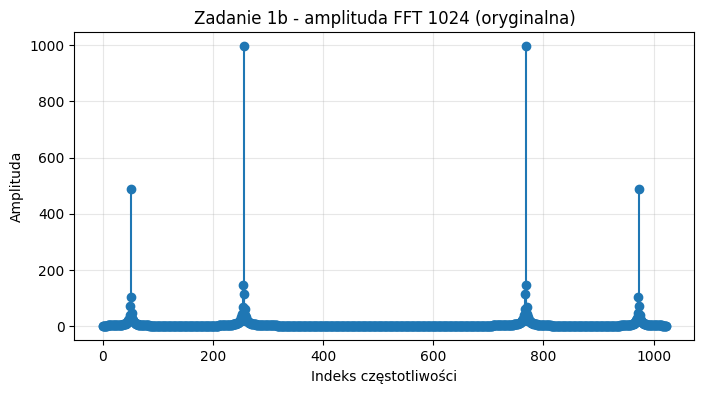

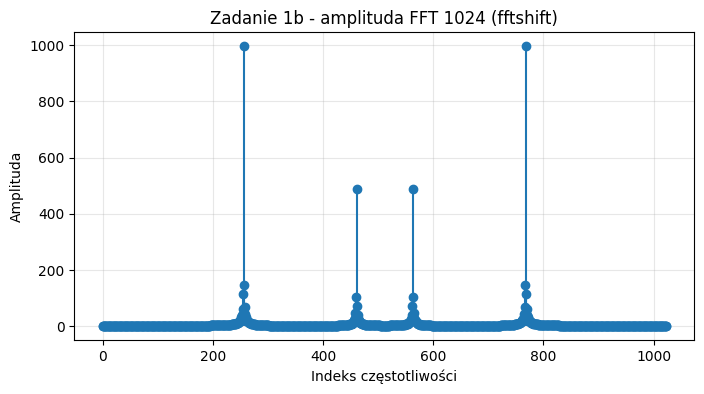

In [15]:
N = 1024
n = np.arange(N)
x = signal_x(n)

X_fft = np.fft.fft(x)

plot_amplitude_spectrum(X_fft, "Zadanie 1b - amplituda FFT 1024 (oryginalna)")
plot_amplitude_spectrum(X_fft, "Zadanie 1b - amplituda FFT 1024 (fftshift)", use_shift=True)

# Zadanie 2

## Zadanie 2a

Wyzeruj składowe o częstotliwości większej niż 2205 Hz.

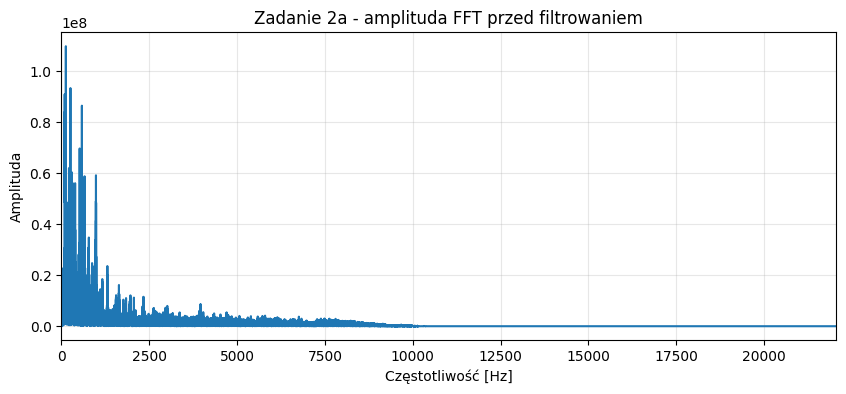

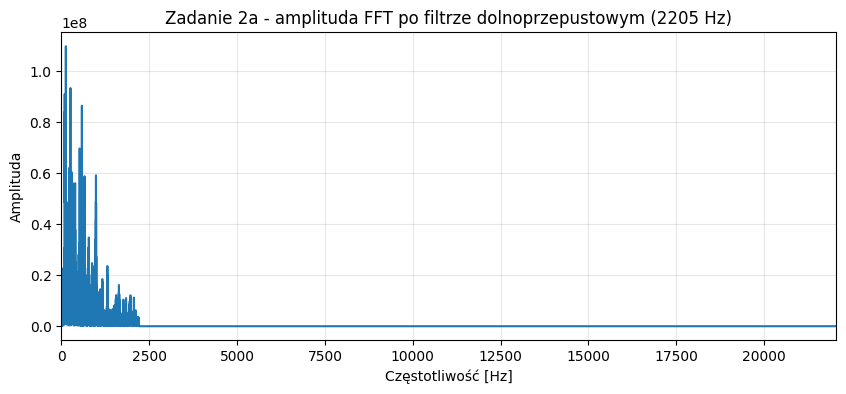

In [16]:
fs, audio = wavfile.read("icing2.wav")
if audio.ndim > 1:
    audio = audio[:, 0]
audio = audio.astype(float)

X = np.fft.fft(audio)
freqs = np.fft.fftfreq(len(audio), d=1 / fs)

X_lp = X.copy()
X_lp[np.abs(freqs) > 2205] = 0

plot_audio_spectrum(X, fs, "Zadanie 2a - amplituda FFT przed filtrowaniem")
plot_audio_spectrum(X_lp, fs, "Zadanie 2a - amplituda FFT po filtrze dolnoprzepustowym (2205 Hz)")

audio_lp = np.fft.ifft(X_lp).real
audio_lp = audio_lp / np.max(np.abs(audio_lp))


def save_audio(path, fs, audio):
    audio_int = np.int16(np.clip(audio, -1, 1) * 32767)
    wavfile.write(path, fs, audio_int)


save_audio("icing2_2a_lowpass.wav", fs, audio_lp)

## Zadanie 2b 

Na transformacie z (a) wyzeruj składowe o częstotliwości mniejszej niż 1103 Hz

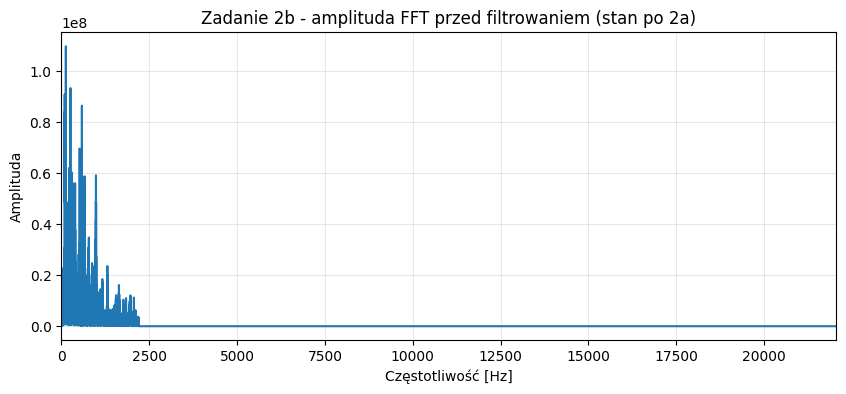

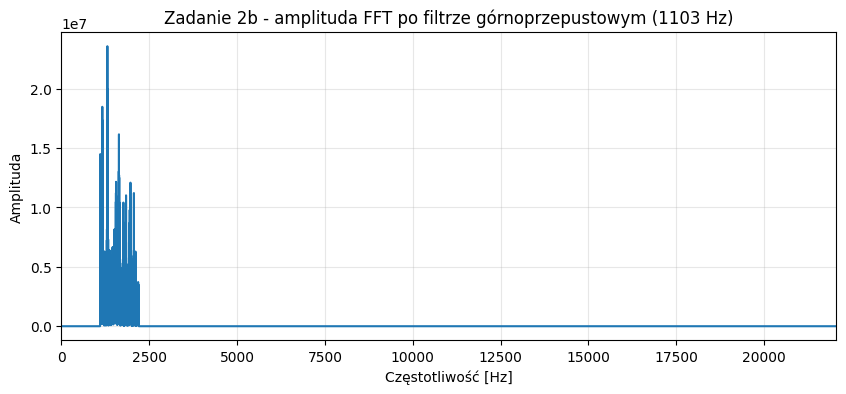

In [17]:
X_hp = X_lp.copy()
X_hp[np.abs(freqs) < 1103] = 0

plot_audio_spectrum(X_lp, fs, "Zadanie 2b - amplituda FFT przed filtrowaniem (stan po 2a)")
plot_audio_spectrum(X_hp, fs, "Zadanie 2b - amplituda FFT po filtrze górnoprzepustowym (1103 Hz)")

audio_hp = np.fft.ifft(X_hp).real
audio_hp = audio_hp / np.max(np.abs(audio_hp))

save_audio("icing2_2b_highpass.wav", fs, audio_hp)

# Zadanie 3

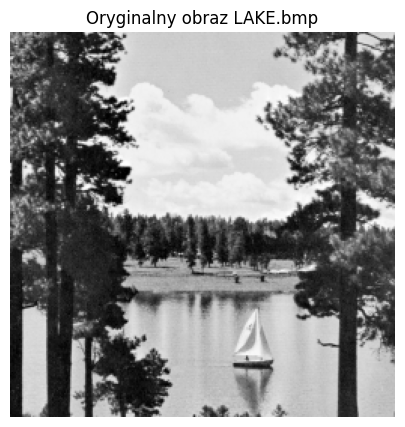

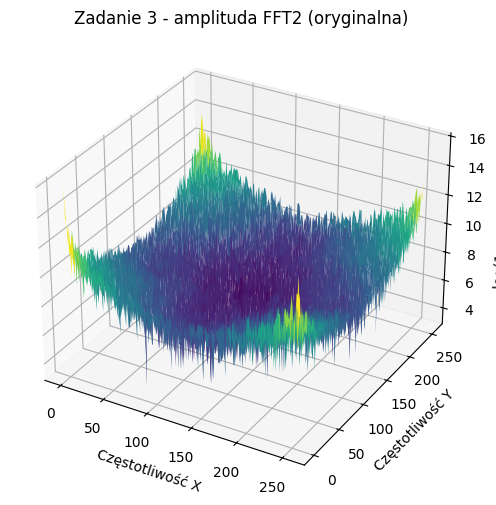

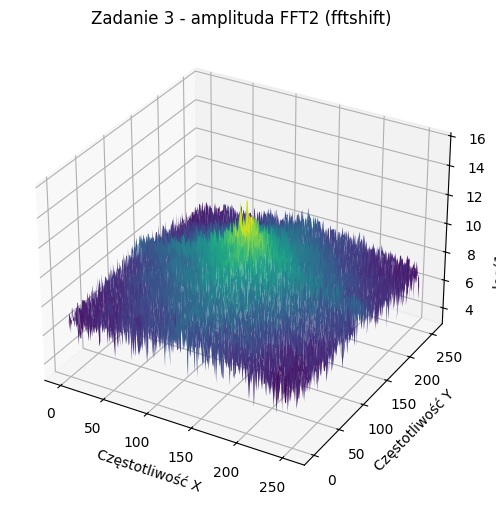

In [18]:
image = cv2.imread("LAKE.bmp", cv2.IMREAD_GRAYSCALE)
image_float = image.astype(float)

F = np.fft.fft2(image_float)

plt.figure(figsize=(6, 5))
plt.imshow(image, cmap="gray")
plt.title("Oryginalny obraz LAKE.bmp")
plt.axis("off")
plt.show()

plot_fft2_mesh(F, "Zadanie 3 - amplituda FFT2 (oryginalna)", use_shift=False)
plot_fft2_mesh(F, "Zadanie 3 - amplituda FFT2 (fftshift)", use_shift=True)

# Zadanie 4

## Zadanie 4a

Wyzeruj składowe, w których |ωx| > π/12.

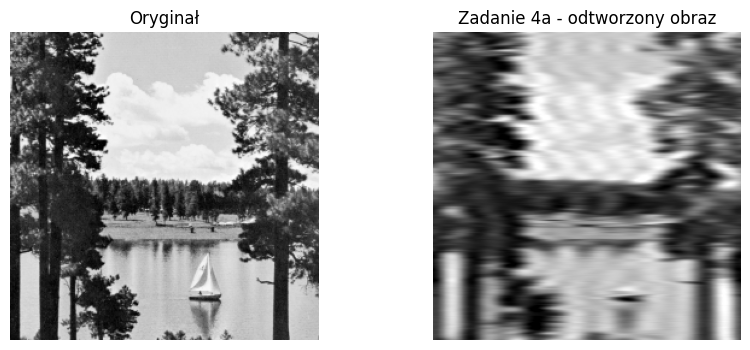

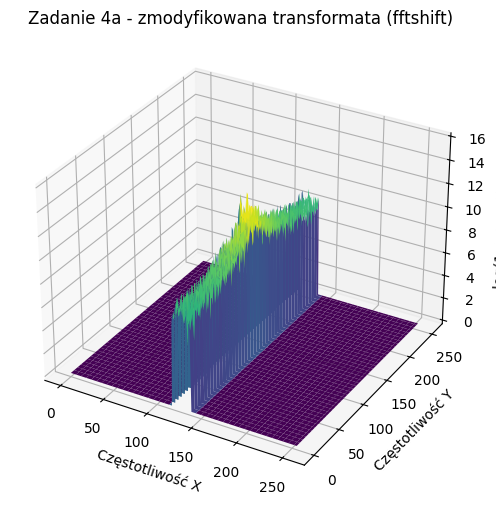

In [19]:
WX, WY = freq_grid_2d(image.shape)

F_4a = F.copy()
F_4a[np.abs(WX) > np.pi / 12] = 0

image_4a = np.fft.ifft2(F_4a).real
image_4a = np.clip(image_4a, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Oryginał")
axes[0].axis("off")
axes[1].imshow(image_4a, cmap="gray")
axes[1].set_title("Zadanie 4a - odtworzony obraz")
axes[1].axis("off")
plt.show()

plot_fft2_mesh(F_4a, "Zadanie 4a - zmodyfikowana transformata (fftshift)", use_shift=True)

## Zadanie 4b

Wyzeruj składowe, w których |ωy| < π/12.

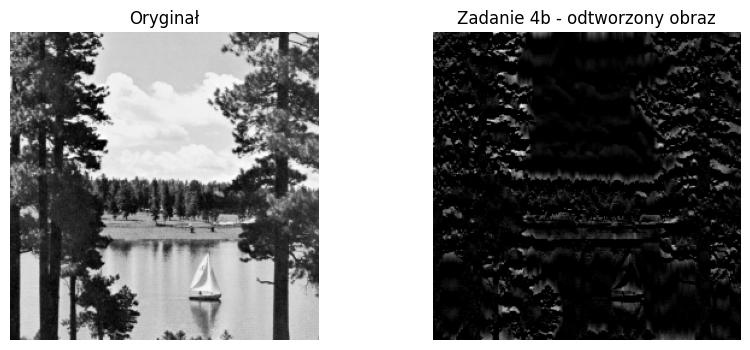

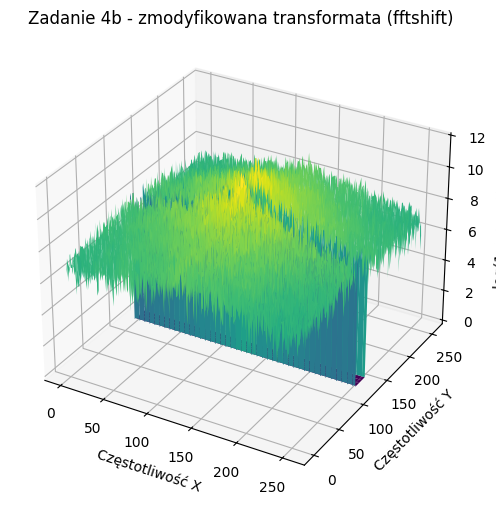

In [20]:
F_4b = F.copy()
F_4b[np.abs(WY) < np.pi / 12] = 0

image_4b = np.fft.ifft2(F_4b).real
image_4b = np.clip(image_4b, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Oryginał")
axes[0].axis("off")
axes[1].imshow(image_4b, cmap="gray")
axes[1].set_title("Zadanie 4b - odtworzony obraz")
axes[1].axis("off")
plt.show()

plot_fft2_mesh(F_4b, "Zadanie 4b - zmodyfikowana transformata (fftshift)", use_shift=True)

## Zadanie 4c

Wyzeruj składowe, w których |ωx| > π/10 lub |ωy| > π/10.

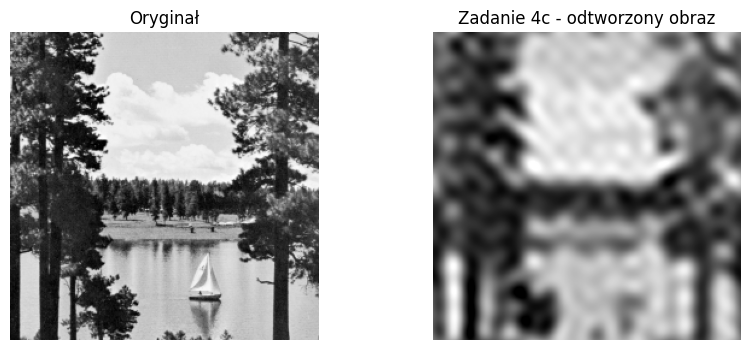

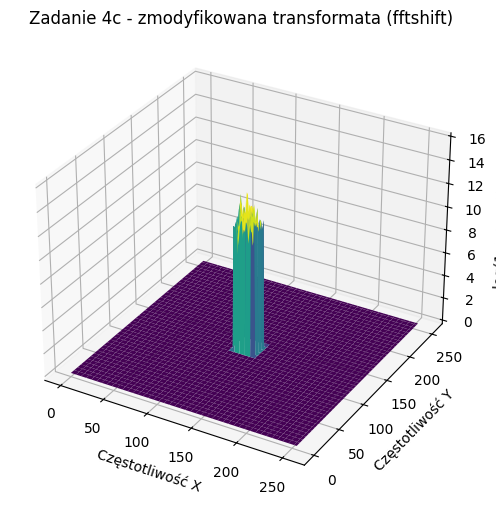

In [21]:
F_4c = F.copy()
mask_4c = (np.abs(WX) > np.pi / 10) | (np.abs(WY) > np.pi / 10)
F_4c[mask_4c] = 0

image_4c = np.fft.ifft2(F_4c).real
image_4c = np.clip(image_4c, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Oryginał")
axes[0].axis("off")
axes[1].imshow(image_4c, cmap="gray")
axes[1].set_title("Zadanie 4c - odtworzony obraz")
axes[1].axis("off")
plt.show()

plot_fft2_mesh(F_4c, "Zadanie 4c - zmodyfikowana transformata (fftshift)", use_shift=True)